# Phase 4: Machine Learning – Book Rating Prediction

## Objective

The objective of this phase is to build a machine learning regression model to predict book ratings using the cleaned book dataset.

The following features are used for prediction:
- Price
- Stock count
- Description length
- Book category

Book rating is used as the target variable.

Two regression algorithms are implemented and compared:
- Random Forest Regression
- Linear Regression

The models are evaluated using:
- Root Mean Squared Error (RMSE)
- R² Score

The best-performing model is then selected, saved, and used as the final regression model.

## 1. Importing Libraries and Loading the Dataset

The required Python libraries and machine learning components are imported.

The cleaned dataset generated during the data cleaning phase is loaded for model development.

In [49]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv("cleaned_books_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 13)


,title,price,rating,availability,product_url,category,upc,stock_count,tax,description,price_category,rating_category,description_length
0,A Light in the Attic,51.77,3,In Stock,https://books.toscrape.com/catalogue/a-light-i...,Poetry,a897fe39b1053632,22,0.0,It's hard to imagine a world without A Light i...,Premium,Average Rated,1017
1,Tipping the Velvet,53.74,1,In Stock,https://books.toscrape.com/catalogue/tipping-t...,Historical Fiction,90fa61229261140a,20,0.0,"""Erotic and absorbing...Written with starling ...",Premium,Low Rated,1029
2,Soumission,50.10,1,In Stock,https://books.toscrape.com/catalogue/soumissio...,Fiction,6957f44c3847a760,20,0.0,"Dans une France assez proche de la nÃ´tre, un ...",Premium,Low Rated,1136
3,Sharp Objects,47.82,4,In Stock,https://books.toscrape.com/catalogue/sharp-obj...,Mystery,e00eb4fd7b871a48,20,0.0,"WICKED above her hipbone, GIRL across her hear...",Premium,Highly Rated,1647
4,Sapiens: A Brief History of Humankind,54.23,5,In Stock,https://books.toscrape.com/catalogue/sapiens-a...,History,4165285e1663650f,20,0.0,From a renowned historian comes a groundbreaki...,Premium,Highly Rated,1969


## 2. Defining Features and Target Variable

The input features and target variable are defined for the regression problem.

### Features
- `price`
- `stock_count`
- `description_length`
- `category`

### Target
- `rating`

The objective is to predict the numerical book rating based on the selected features.

In [32]:
# Define features and target for regression

X = df[["price", "stock_count", "description_length", "category"]]
y = df["rating"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("rating")

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['price', 'stock_count', 'description_length', 'category']

Target:
rating

Feature shape: (1000, 4)
Target shape: (1000,)


## 3. Train-Test Split

The dataset is divided into training and testing sets.

80% of the data is used for training the models, while 20% is reserved for testing their predictive performance.

A fixed random state of 42 is used to ensure reproducible results.

In [33]:
# Split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (800, 4)
Testing feature shape: (200, 4)
Training target shape: (800,)
Testing target shape: (200,)


## 4. Data Preprocessing

The numerical and categorical features require different preprocessing approaches.

The numerical features are passed directly to the models, while the categorical `category` feature is converted into numerical form using One-Hot Encoding.

`handle_unknown="ignore"` is used so that unseen categories in the test data do not cause errors.

In [34]:
# Prepare preprocessing for regression

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = ["price", "stock_count", "description_length"]
categorical_features = ["category"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['price', 'stock_count', 'description_length']
Categorical features: ['category']


## 5. Building the Random Forest Regression Model

A Random Forest Regression model is created using a machine learning pipeline.

The pipeline combines the preprocessing step with the Random Forest Regressor so that preprocessing and model prediction are performed consistently.

In [35]:
# Build Random Forest Regression pipeline

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ))
    ]
)

print("Regression model created successfully.")

Regression model created successfully.


## 6. Training the Random Forest Regression Model

The Random Forest regression model is trained using the training dataset.

The model learns relationships between the selected book features and the book rating.

In [36]:
# Train the Random Forest regression model

regression_model.fit(X_train, y_train)

print("Regression model trained successfully.")

Regression model trained successfully.


## 7. Evaluating Random Forest Regression

Predictions are generated using the test dataset.

The model is evaluated using RMSE and R² Score.

### Results

- **RMSE:** 1.5236
- **R² Score:** -0.1328

The results indicate that the Random Forest model has limited predictive ability for book ratings using the available features.

In [37]:
# Make predictions on the test data

from sklearn.metrics import mean_squared_error, r2_score

y_pred = regression_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Regression Results")
print("RMSE:", round(rmse, 4))
print("R² Score:", round(r2, 4))

Random Forest Regression Results
RMSE: 1.5236
R² Score: -0.1328


## 8. Building the Linear Regression Model

A Linear Regression model is created as a second regression approach.

The same preprocessing pipeline and input features are used so that the performance can be compared fairly with the Random Forest model.

In [38]:
# Build Linear Regression pipeline

from sklearn.linear_model import LinearRegression

linear_regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

print("Linear Regression model created successfully.")

Linear Regression model created successfully.


## 9. Training the Linear Regression Model

The Linear Regression model is trained using the same training dataset used for the Random Forest model.

In [39]:
# Train the Linear Regression model

linear_regression_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 10. Evaluating Linear Regression

Predictions are generated on the test dataset and evaluated using RMSE and R² Score.

### Results

- **RMSE:** 1.5244
- **R² Score:** -0.1341

The Linear Regression model performs slightly worse than the Random Forest model based on both evaluation metrics.

In [40]:
# Evaluate Linear Regression model

y_pred_linear = linear_regression_model.predict(X_test)

rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("RMSE:", round(rmse_linear, 4))
print("R² Score:", round(r2_linear, 4))

Linear Regression Results
RMSE: 1.5244
R² Score: -0.1341


## 11. Comparing Regression Models

The performance of Random Forest Regression and Linear Regression is compared using RMSE and R² Score.

For RMSE, a lower value indicates better performance.

For R² Score, a higher value indicates better performance.

The comparison is used to select the final regression model.

In [41]:
# Compare regression models

model_comparison = pd.DataFrame({
    "Model": ["Random Forest Regression", "Linear Regression"],
    "RMSE": [rmse, rmse_linear],
    "R2 Score": [r2, r2_linear]
})

print(model_comparison)

                      Model      RMSE  R2 Score
0  Random Forest Regression  1.523562 -0.132810
1         Linear Regression  1.524447 -0.134127


## 12. Selecting the Final Model

Based on the evaluation results, Random Forest Regression is selected as the final model because it achieves a slightly lower RMSE and a slightly higher R² Score than Linear Regression.

### Final Model

**Random Forest Regression**

- RMSE: **1.5236**
- R² Score: **-0.1328**

The negative R² score indicates that the available features do not explain the variation in book ratings well. This is an important finding from the modelling phase rather than a model failure.

In [42]:
# Select the best regression model

final_model = regression_model
final_rmse = rmse
final_r2 = r2

print("Final Model: Random Forest Regression")
print("Final RMSE:", round(final_rmse, 4))
print("Final R² Score:", round(final_r2, 4))

Final Model: Random Forest Regression
Final RMSE: 1.5236
Final R² Score: -0.1328


## 13. Saving the Final Regression Model

The selected Random Forest regression pipeline is saved as a Joblib file.

Saving the complete pipeline allows the preprocessing steps and trained model to be reused later without retraining from scratch.

In [43]:
# Save the final regression model

import joblib

joblib.dump(final_model, "final_book_rating_regression_model.joblib")

print("Final regression model saved successfully.")

Final regression model saved successfully.


## 14. Verifying the Saved Model

The saved model file is checked to confirm that the final regression model has been successfully stored.

This ensures that the trained model is available for future prediction or deployment.

In [44]:
# Verify that the final regression model was saved

import os

model_file = "final_book_rating_regression_model.joblib"

print("Model file exists:", os.path.exists(model_file))

if os.path.exists(model_file):
    print("File size:", round(os.path.getsize(model_file) / 1024, 2), "KB")

Model file exists: True
File size: 13307.15 KB


## 15. Saving Model Comparison Results

The performance comparison between the two regression models is saved as a CSV file.

This provides a record of the RMSE and R² Score results for both models.

In [45]:
# Save regression model comparison results

model_comparison.to_csv("regression_model_comparison.csv", index=False)

print("Regression model comparison saved successfully.")
print("\nSaved results:")
print(model_comparison)

Regression model comparison saved successfully.

Saved results:
                      Model      RMSE  R2 Score
0  Random Forest Regression  1.523562 -0.132810
1         Linear Regression  1.524447 -0.134127


## 16. Visual Comparison of RMSE

A bar chart is created to compare the RMSE values of Random Forest Regression and Linear Regression.

Since lower RMSE represents better prediction performance, the chart helps visually identify the better-performing model.

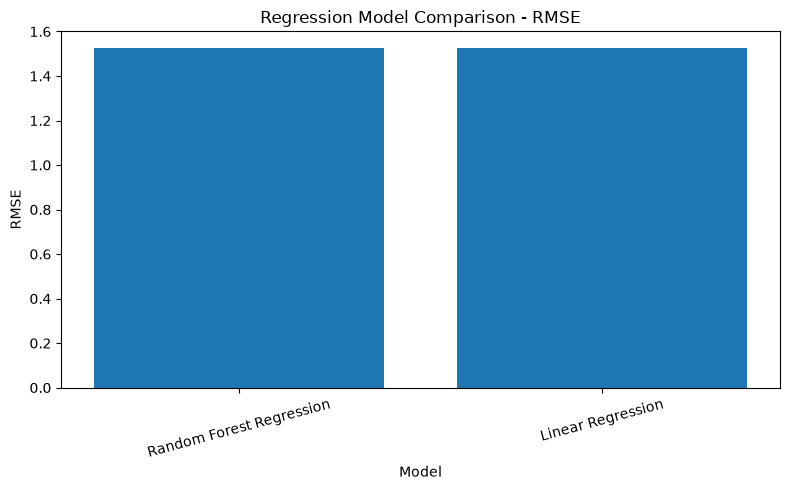

In [46]:
# Compare regression model performance visually

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["RMSE"]
)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Regression Model Comparison - RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 17. Visual Comparison of R² Score

A bar chart is created to compare the R² Scores of the two regression models.

A higher R² Score represents better explanatory and predictive performance.

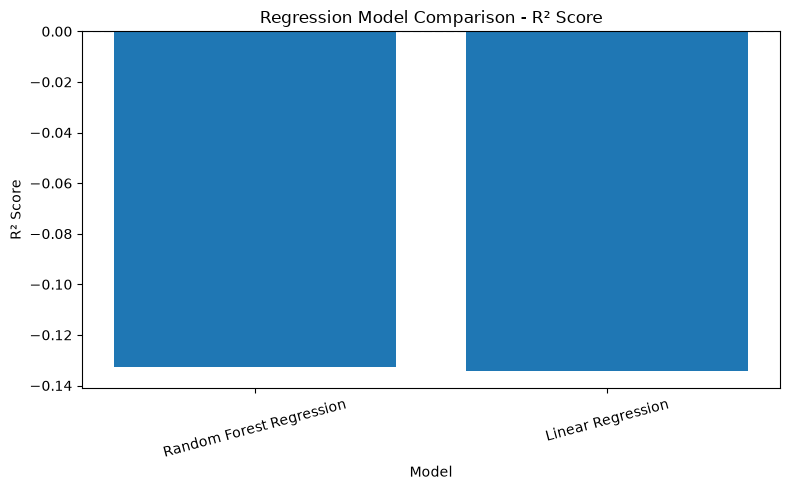

In [47]:
# Compare regression model performance using R²

plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["R2 Score"]
)

plt.ylabel("R² Score")
plt.xlabel("Model")
plt.title("Regression Model Comparison - R² Score")
plt.xticks(rotation=15)
plt.axhline(y=0, linestyle="--")
plt.tight_layout()
plt.show()

In [48]:
# Final regression model summary

print("========== PHASE 4: MACHINE LEARNING ==========")
print("Problem Type: Regression")
print("Target: Book Rating")
print()
print("Models Evaluated:")
print("1. Random Forest Regression")
print("2. Linear Regression")
print()
print("Best Model: Random Forest Regression")
print("RMSE:", round(final_rmse, 4))
print("R² Score:", round(final_r2, 4))
print()
print("Conclusion:")
print("The Random Forest model performed slightly better than Linear Regression.")
print("However, the negative R² score indicates that the available features")
print("have limited ability to predict the book ratings in this dataset.")

========== PHASE 4: MACHINE LEARNING ==========
Problem Type: Regression
Target: Book Rating

Models Evaluated:
1. Random Forest Regression
2. Linear Regression

Best Model: Random Forest Regression
RMSE: 1.5236
R² Score: -0.1328

Conclusion:
The Random Forest model performed slightly better than Linear Regression.
However, the negative R² score indicates that the available features
have limited ability to predict the book ratings in this dataset.


# 18. Final Machine Learning Summary

The machine learning phase implemented a regression approach to predict book ratings.

### Models Evaluated

1. Random Forest Regression
2. Linear Regression

### Model Performance

| Model | RMSE | R² Score |
|---|---:|---:|
| Random Forest Regression | 1.5236 | -0.1328 |
| Linear Regression | 1.5244 | -0.1341 |

### Final Model

**Random Forest Regression** was selected because it achieved the lowest RMSE and the highest R² Score among the two tested models.

The negative R² score indicates that the selected features have weak predictive power for book ratings. The EDA also showed very weak relationships between rating and the available numerical variables.

Therefore, the model results provide an important insight: **book ratings cannot be reliably predicted from price, stock count, description length, and category alone in this dataset.**

The final trained model has been saved as:

`final_book_rating_regression_model.joblib`

The model comparison results have been saved as:

`regression_model_comparison.csv`